# PyTorch DL Skeleton

- Dataset loading and preparation
- Architecture implementation
- Training, evaluation
- Analysis of parameters

- groups 1,3 : 8h30-10h00
- groups 2,4: 10h45 - 12h15
- doc / internet autorisé
- notre ordi autorisé, docs autorisé 

## Imports and device

In [ ]:
import torch
import torch.nn as nn
# Can use F.relu() in forward, more flexible but more manual than nn.ReLU():\
# import torch.nn.functional as F 
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import numpy as np

from tqdm import tqdm
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cpu


## Dataset and DataLoader

### Load dataset from internet

In [ ]:
from torchvision import datasets, transforms # as well torchtext and torchaudio

transform = transforms.Compose([
    transforms.ToTensor(), # [0,255] → [0,1]
    # Normalize((0.5,), (0.5,)) is fine for grayscale MNIST, 
    # but if you use RGB images, you’ll need 3 values for mean/std: 
    # (0.5,0.5,0.5) each.
    transforms.Normalize((0.5,), (0.5,)) # roughly [-1,1]
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

100%|██████████| 9.91M/9.91M [00:06<00:00, 1.65MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 353kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.65MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.35MB/s]


### Or make one yourself

In [ ]:
class DummyDataset(Dataset):
    def __init__(self, n_samples=100, n_features=20, n_classes=2):
        # can e.g. load a dataset from file here
        from sklearn.datasets import make_classification
        X, y = make_classification(
            n_samples=n_samples, n_features=n_features, n_informative=n_features,
            n_redundant=0, n_classes=n_classes, class_sep=2.0, random_state=42
        )
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]
    
dataset = DummyDataset()

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

# NOTE: random_split keeps the same device as original tensors (CPU by default),
# so remember to .to(device) in training loop if using GPU.
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

### Convert to DataLoader

In [ ]:
batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True) # necessary for SGD randomness
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False) # reproducible evaluation order
# NOTE: num_workers=2 or more for faster data loading if needed

## Architecture templates

In [ ]:
class MLP(nn.Module):

    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )
    
    def forward(self, x):
        
        return self.model(x)

If you need to a flexible number of hidden layers:

In [ ]:
class FlexibleMLP(nn.Module):
    def __init__(self, input_dim, hidden_dims, output_dim, activation=nn.ReLU):
        super().__init__()
        layers = []
        dims = [input_dim] + hidden_dims
        for i in range(len(dims)-1):
            layers.append(nn.Linear(dims[i], dims[i+1]))
            layers.append(activation())
        layers.append(nn.Linear(dims[-1], output_dim))
        self.model = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.model(x)

In [ ]:
class CNN(nn.Module):
    def __init__(self,input_shape=(1,28,28), num_classes=10):
        super().__init__()

        in_channels = input_shape[0]

        self.features = nn.Sequential(
            nn.Conv2d(in_channels,16,kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # --- dummy forward pass ---
        with torch.no_grad():
            dummy = torch.zeros(1,*input_shape)
            dummy_out = self.features(dummy)
            n_features = dummy_out.numel()

        self.classifier = nn.Sequential(
            nn.Linear(n_features, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1) # flatten feature dimensions, keep batch dimension intact
        x = self.classifier(x)
        return x

In [ ]:
class RNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers=1, rnn_type='LSTM'):
        super().__init__()

        if rnn_type == 'LSTM':
            self.rnn = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        elif rnn_type == 'GRU':
            self.rnn = nn.GRU(input_dim, hidden_dim, num_layers, batch_first=True)
        elif rnn_type == "RNN":
            self.rnn = nn.RNN(input_dim, hidden_dim, num_layers, batch_first=True)
        else:
            raise ValueError
        
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        out, _ = self.rnn(x) # for LSTM, _ actually contains (h_n, c_n). For GRU/RNN, _ is just h_n
        out = out[:,-1,:] # last timestep
        out = self.fc(out)
        return out

In [7]:
model = MLP(input_dim=20, hidden_dim=64, output_dim=2).to(device)

## Loss, Optimizer

In [8]:
criterion = nn.CrossEntropyLoss() # expects raw logits, targets are class indices (not one-hot)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

## Training Loop

In [9]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for X, y in loader:
        X, y = X.to(device), y.to(device)

        optimizer.zero_grad()

        outputs = model(X)
        loss = criterion(outputs, y)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X.size(0)

        _, predicted = torch.max(outputs, 1) # equiv to outputs.argmax(1)
        correct += (predicted == y).sum().item()
        total += y.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc


## Evaluation Loop

In [10]:
def evaluate(model, loader, criterion):
    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)

            outputs = model(X)
            loss = criterion(outputs, y)

            running_loss += loss.item() * X.size(0)

            _, predicted = torch.max(outputs, 1)
            correct += (predicted == y).sum().item()
            total += y.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

## Full training

In [ ]:
num_epochs = 10

history = {
    "train_loss": [],
    "train_acc": [],
    "test_loss": [],
    "test_acc": []
}

for epoch in tqdm(range(num_epochs)):

    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    test_loss, test_acc = evaluate(model, test_loader, criterion)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["test_loss"].append(test_loss)
    history["test_acc"].append(test_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}]",
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}",
          f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")

100%|██████████| 10/10 [00:00<00:00, 304.87it/s]

Epoch [1/10] Train Loss: 0.6753 | Train Acc: 0.6250 Test Loss: 0.6718 | Test Acc: 0.5000
Epoch [2/10] Train Loss: 0.5879 | Train Acc: 0.8000 Test Loss: 0.6168 | Test Acc: 0.7500
Epoch [3/10] Train Loss: 0.5181 | Train Acc: 0.9250 Test Loss: 0.5685 | Test Acc: 0.7500
Epoch [4/10] Train Loss: 0.4562 | Train Acc: 0.9375 Test Loss: 0.5183 | Test Acc: 0.8000
Epoch [5/10] Train Loss: 0.3965 | Train Acc: 0.9500 Test Loss: 0.4708 | Test Acc: 0.8500
Epoch [6/10] Train Loss: 0.3417 | Train Acc: 0.9750 Test Loss: 0.4206 | Test Acc: 0.8000
Epoch [7/10] Train Loss: 0.2920 | Train Acc: 0.9625 Test Loss: 0.3800 | Test Acc: 0.7500
Epoch [8/10] Train Loss: 0.2493 | Train Acc: 0.9625 Test Loss: 0.3467 | Test Acc: 0.8000
Epoch [9/10] Train Loss: 0.2123 | Train Acc: 0.9625 Test Loss: 0.3176 | Test Acc: 0.8000
Epoch [10/10] Train Loss: 0.1790 | Train Acc: 0.9750 Test Loss: 0.2923 | Test Acc: 0.8500


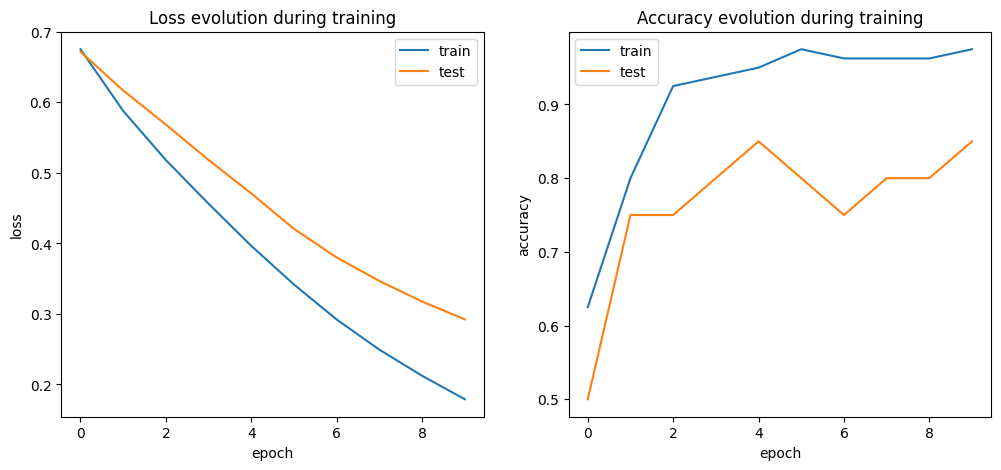

In [17]:
fig, axes = plt.subplots(1,2, figsize = (12,5))

axes[0].set_title("Loss evolution during training")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss")
axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["test_loss"], label="test")
axes[0].legend()

axes[1].set_title("Accuracy evolution during training")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("accuracy")
axes[1].plot(history["train_acc"], label="train")
axes[1].plot(history["test_acc"], label="test")
axes[1].legend()

plt.show()


## Analyze parameters

### Activations maps for CNN

In [ ]:
# Hook to capture outputs
activation = {}
def get_activation(name):
    def hook(model, input, output):
        activation[name] = output.detach()
    return hook

model.features[0].register_forward_hook(get_activation("conv1"))

# Forward pass
x, _ = next(iter(train_loader))
x = x.to(device)
_ = model(x)

print(activation["conv1"].shape)  # e.g., (batch_size, 16, 28, 28)

### Gradients

w.r.t. inputs - usually for visualization or adversarial examples, not for standard training

In [14]:
x, y = next(iter(train_loader))
x, y = x.to(device), y.to(device)
x.requires_grad = True

outputs = model(x)
loss = criterion(outputs, y)
loss.backward()

print(x.grad.shape)

torch.Size([32, 20])


w.r.t. to parameters

In [19]:
# NOTE: useful for monitoring vanishing or exploding gradients per epoch
def get_gradients(model):
    grad_norms = {}
    for name, param in model.named_parameters():
        if param.grad is not None:
            grad_norms[name] = param.grad.norm(2).item()
    return grad_norms

get_gradients(model)

{'model.0.weight': 0.4929783344268799,
 'model.0.bias': 0.040908753871917725,
 'model.2.weight': 0.5112043023109436,
 'model.2.bias': 0.046911660581827164,
 'model.4.weight': 0.7197961211204529,
 'model.4.bias': 0.09172879159450531}

# Avoid pitfalls

#### Dataset & Dataloader

- `shuffle=True` for training DataLoader, `shuffle=False` for test
- start with 32-64 batch size (too small - noisy training, too large - memory error)
- `CrossEntropyLoss` use integers of shape `(batch_size,)` for targets, not one-hot

#### Model Architecture

- `x = x.to(device)` at the beginning of `forward()` if needed 
- `output_dim` should match number of classes
- output raw logits (don't apply softmax, it's integrated in `CrossEntropyLoss`!)
- shapes: 
    - CNN: `(batch_size, channels, H, W)` 
        - `in_channels` = 1 if grayscale, 3 if RGB
    - RNN: `(batch_size, seq_len, features)`
    - flatten before linear: `x = torch.flatten(x,1)`
    - use dummy tensor to compute dim after convolutions and pooling

#### Loss & Optimizer

- `CrossEntropyLoss` use integers of shape `(batch_size,)` for targets, not one-hot
- `optimizer.zero_grad()`

#### Training Loop

- send `X`, `y` to device
- use raw logits for `CrossEntropyLoss` 
- `model.train()`
- if gradients vanish or explode, use `ReLU` and check learning rate

#### Evaluation Loop

- `torch.no_grad()` - saves memory
- `model.eval()`
- track separate loss and score for test set
- if gradients explodes, check learning rate or clip gradient:
```py
loss.backward()
torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
optimizer.step()
```
- check `param.grad` after `loss.backward()`
